# **Análisis Exploratorio de Datos**

En este notebook analizamos en profundidad el dataset MIT-BIH para entender
mejor los datos antes de entrenar el modelo. El EDA nos ayuda a detectar
posibles problemas, entender el desbalance de clases y visualizar las
diferencias morfológicas entre latidos normales y anormales.

In [ ]:
# Montar Drive si usamos Colab (comentar si ejecutamos en local)
# from google.colab import drive
# drive.mount('/content/drive')
# os.chdir("/content/drive/MyDrive/Colab Notebooks/ECGAssistant_Sprint1")

import os
print("Directorio:", os.getcwd())
print("Archivos:", os.listdir())

Mounted at /content/drive
Directorio: /content/drive/.shortcut-targets-by-id/1acOp95JDTEWtgyHkn2BDLpHG-oeo8sXh/ECGAssistant_Sprint1
Archivos: ['mitdb', 'X_train.npy', 'X_val.npy', 'X_test.npy', 'y_train.npy', 'y_val.npy', 'y_test.npy', '03_evaluation.ipynb', 'rag_documents', '01_preprocessing.ipynb', '02_model_training.ipynb', 'ecg_model.pth', 'ecg_qa_dataset.jsonl', 'faiss_index.bin', 'chunks.json', '04_ECG_QA_Dataset.ipynb', '07_Rag_faiss.ipynb', '06_finetune_gemma3_qlora.ipynb', 'google', 'gemma3_qlora', '08_pipeline_end_to_end.ipynb']


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Cargamos los datos preprocesados generados en el notebook anterior
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")
X_test  = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_val   = np.load("y_val.npy")
y_test  = np.load("y_test.npy")

# Juntamos todo para el análisis exploratorio
X_all = np.concatenate([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

print(f"Total muestras: {X_all.shape[0]}")
print(f"Longitud de cada latido: {X_all.shape[1]} muestras")

Total muestras: 73737
Longitud de cada latido: 288 muestras


## 1. Distribución de clases

Revisamos cuántos latidos normales y anormales hay en el dataset completo
y en cada split.

In [6]:
# Distribución global
unique, counts = np.unique(y_all, return_counts=True)
total = len(y_all)

print("Distribución global:")
for u, c in zip(unique, counts):
    label = "Normal" if u == 0 else "Anormal"
    print(f"  {label} ({u}): {c:,} latidos ({c/total*100:.1f}%)")

print(f"\nDesbalance: hay {counts[0]//counts[1]:.1f}x más latidos normales que anormales")

Distribución global:
  Normal (0): 52,242 latidos (70.8%)
  Anormal (1): 21,495 latidos (29.2%)

Desbalance: hay 2.0x más latidos normales que anormales


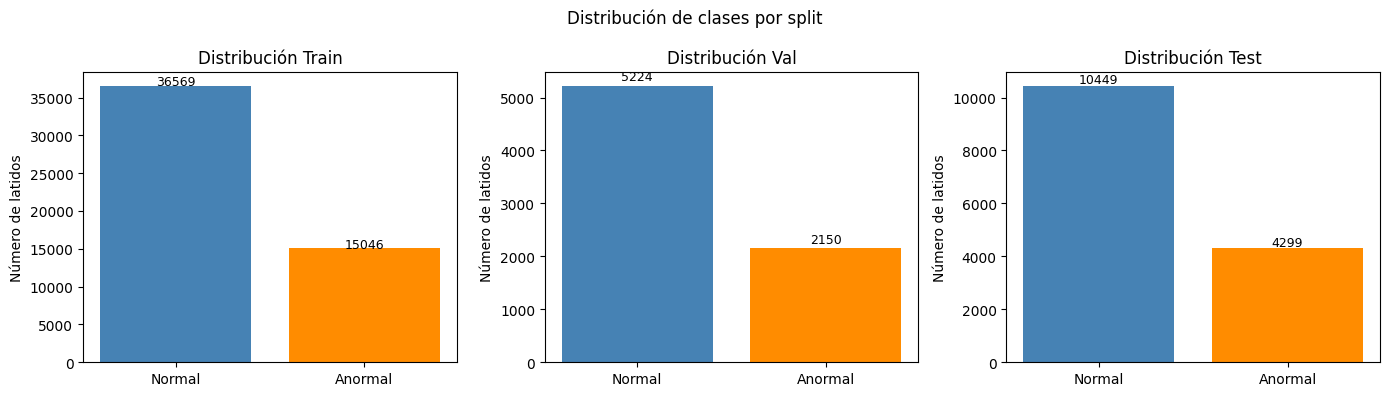

In [7]:
# Distribución por split
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

splits = {
    "Train": y_train,
    "Val"  : y_val,
    "Test" : y_test
}

for ax, (nombre, y) in zip(axes, splits.items()):
    u, c = np.unique(y, return_counts=True)
    ax.bar(["Normal", "Anormal"], c, color=["steelblue", "darkorange"])
    ax.set_title(f"Distribución {nombre}")
    ax.set_ylabel("Número de latidos")
    for i, v in enumerate(c):
        ax.text(i, v + 100, str(v), ha="center", fontsize=9)

plt.suptitle("Distribución de clases por split", fontsize=12)
plt.tight_layout()
plt.show()

## 2. Estadísticas de las señales

Analizamos las características estadísticas de las señales para entender
su distribución de amplitudes.

Estadísticas del conjunto completo (antes de normalizar):
  Media:                -0.0022 mV
  Desviación estándar:  0.9988 mV
  Valor mínimo:         -9.9362 mV
  Valor máximo:         11.4018 mV


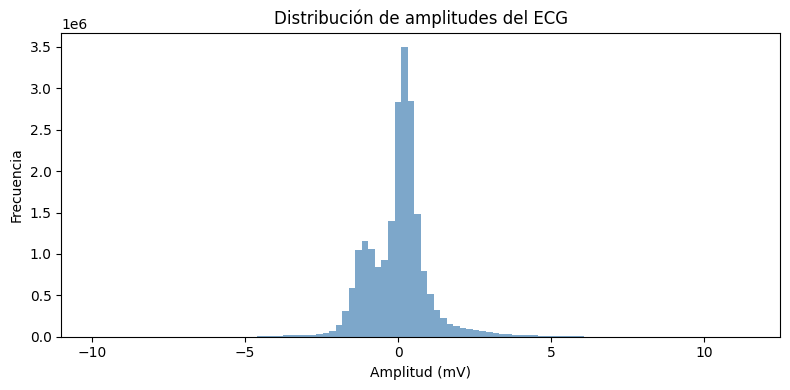

In [8]:
print("Estadísticas del conjunto completo (antes de normalizar):")
print(f"  Media:                {X_all.mean():.4f} mV")
print(f"  Desviación estándar:  {X_all.std():.4f} mV")
print(f"  Valor mínimo:         {X_all.min():.4f} mV")
print(f"  Valor máximo:         {X_all.max():.4f} mV")

# Histograma de amplitudes
plt.figure(figsize=(8, 4))
plt.hist(X_all.flatten(), bins=100, color="steelblue", alpha=0.7)
plt.title("Distribución de amplitudes del ECG")
plt.xlabel("Amplitud (mV)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

## 3. Morfología de los latidos

Comparamos visualmente la forma de los latidos normales y anormales.
Esta es la información que la CNN tendrá que aprender a distinguir.

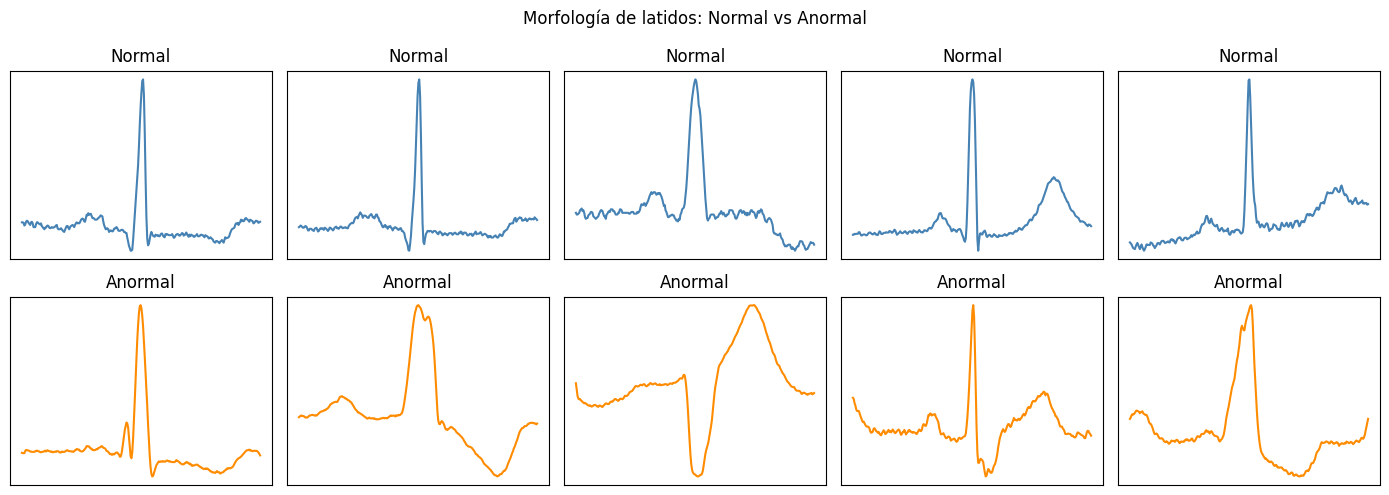

In [9]:
# 5 ejemplos de cada clase
normal_idx   = np.where(y_all == 0)[0][:5]
abnormal_idx = np.where(y_all == 1)[0][:5]

fig, axes = plt.subplots(2, 5, figsize=(14, 5))

for i, idx in enumerate(normal_idx):
    axes[0, i].plot(X_all[idx], color="steelblue")
    axes[0, i].set_title("Normal")
    axes[0, i].set_xticks([])
    axes[0, i].set_yticks([])

for i, idx in enumerate(abnormal_idx):
    axes[1, i].plot(X_all[idx], color="darkorange")
    axes[1, i].set_title("Anormal")
    axes[1, i].set_xticks([])
    axes[1, i].set_yticks([])

plt.suptitle("Morfología de latidos: Normal vs Anormal", fontsize=12)
plt.tight_layout()
plt.show()

## 4. Latido promedio por clase

Calculamos el latido medio de cada clase para ver de forma más clara
las diferencias morfológicas entre un latido normal y uno anormal.

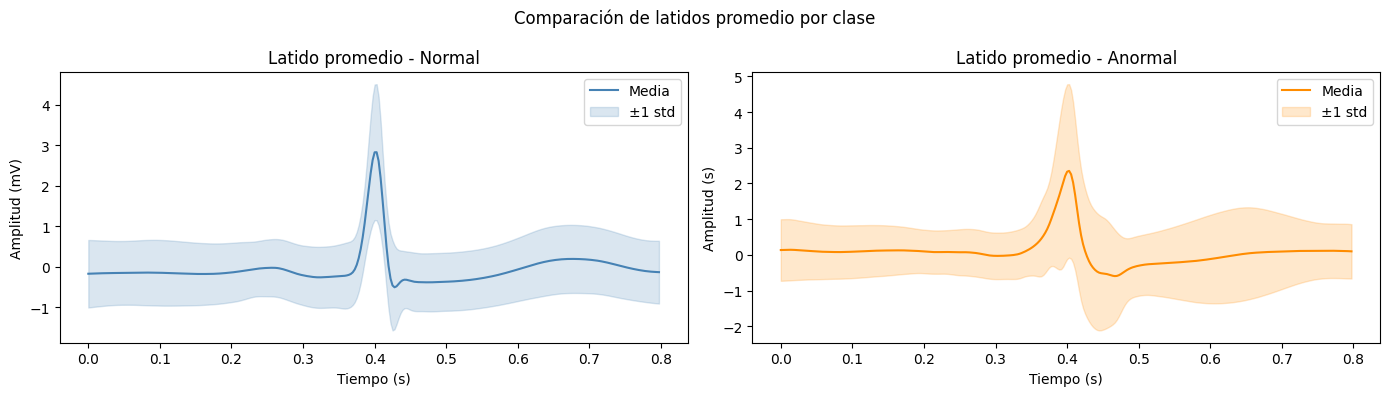

In [10]:
media_normal   = X_all[y_all == 0].mean(axis=0)
media_anormal  = X_all[y_all == 1].mean(axis=0)
std_normal     = X_all[y_all == 0].std(axis=0)
std_anormal    = X_all[y_all == 1].std(axis=0)

t = np.arange(X_all.shape[1]) / 360  # convertimos a segundos (360 Hz)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t, media_normal, color="steelblue", label="Media")
axes[0].fill_between(t,
    media_normal - std_normal,
    media_normal + std_normal,
    alpha=0.2, color="steelblue", label="±1 std")
axes[0].set_title("Latido promedio - Normal")
axes[0].set_xlabel("Tiempo (s)")
axes[0].set_ylabel("Amplitud (mV)")
axes[0].legend()

axes[1].plot(t, media_anormal, color="darkorange", label="Media")
axes[1].fill_between(t,
    media_anormal - std_anormal,
    media_anormal + std_anormal,
    alpha=0.2, color="darkorange", label="±1 std")
axes[1].set_title("Latido promedio - Anormal")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Amplitud (s)")
axes[1].legend()

plt.suptitle("Comparación de latidos promedio por clase", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Distribución de amplitudes por clase

Comparamos la distribución de amplitudes de los latidos normales y anormales
para ver si hay diferencias estadísticas claras entre ambas clases.

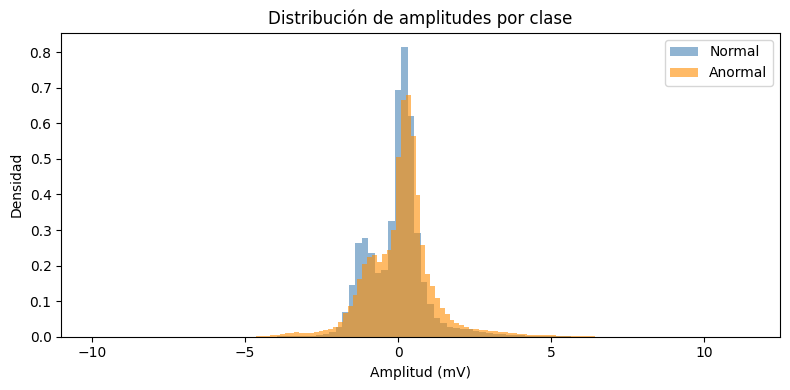

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(X_all[y_all == 0].flatten(), bins=100, alpha=0.6,
         color="steelblue", label="Normal", density=True)
plt.hist(X_all[y_all == 1].flatten(), bins=100, alpha=0.6,
         color="darkorange", label="Anormal", density=True)
plt.title("Distribución de amplitudes por clase")
plt.xlabel("Amplitud (mV)")
plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

## Reflexión

El EDA nos confirma varias cosas importantes:

- El dataset tiene un desbalance de ~70/30 entre normales y anormales.
  No es un desbalance extremo pero hay que tenerlo en cuenta en el
  entrenamiento, usando pesos de clase en la función de pérdida.
- Los latidos normales tienen una morfología más homogénea y consistente,
  mientras que los anormales presentan mayor variabilidad en su forma,
  lo que tiene sentido clínicamente.
- Las diferencias morfológicas entre clases son visibles a simple vista
  en el latido promedio, lo que indica que la CNN debería ser capaz de
  aprender a distinguirlas.

El siguiente notebook implementa y entrena la arquitectura CNN.